# Uses 'SampleData2.csv'

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

data = pd.read_csv("SampleData2.csv")
data

,SubjID,Decision1,Bias1,Decision2,Bias2,Decision3,Bias3,HealthStatus
0,1,0,1,5,1,2,1,85
1,2,3,1,3,1,0,1,75
2,3,1,0,5,0,1,0,95
3,4,4,0,4,1,5,1,80
4,5,4,0,2,1,1,1,95
...,...,...,...,...,...,...,...,...
195,196,3,0,0,0,3,0,75
196,197,4,0,3,1,1,1,100
197,198,1,1,2,0,0,0,85
198,199,2,0,4,0,3,0,95


In [2]:
# lists
subjID_list = data["SubjID"].values.tolist()
d1 = data["Decision1"].values.tolist()
d2 = data["Decision2"].values.tolist()
d3 = data["Decision3"].values.tolist()

In [3]:
#d1_list = [d1.count(0), d1.count(1), d1.count(2), d1.count(3), d1.count(4), d1.count(5)]
#d2_list = [d2.count(0), d2.count(1), d2.count(2), d2.count(3), d2.count(4), d2.count(5)]
#d3_list = [d3.count(0), d3.count(1), d3.count(2), d3.count(3), d3.count(4), d3.count(5)]

zero = [d1.count(0), d2.count(0), d3.count(0)]
one = [d1.count(1), d2.count(1), d3.count(1)]
two = [d1.count(2), d2.count(2), d3.count(2)]
three = [d1.count(3), d2.count(3), d3.count(3)]
four = [d1.count(4), d2.count(4), d3.count(4)]
five = [d1.count(5), d2.count(5), d3.count(5)]

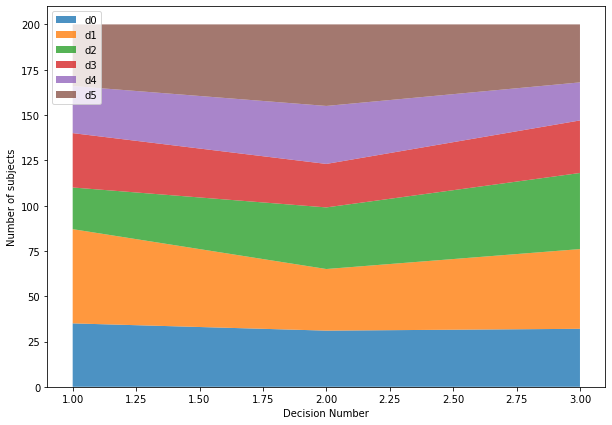

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#code = [0, 1, 2, 3, 4, 5]
#num = {'d1': d1_list, 'd2': d2_list, 'd3': d3_list}

code = [1, 2, 3]
num = {'d0': zero, 'd1': one, 'd2': two, 'd3': three, 'd4': four, 'd5': five}

fig, ax = plt.subplots(figsize=(10, 7))
ax.stackplot(code, num.values(), labels=num.keys(), alpha=0.8, )

ax.legend(loc='upper left')
#ax.set_title('World population')
ax.set_xlabel('Decision Number')
ax.set_ylabel('Number of subjects')

plt.show()

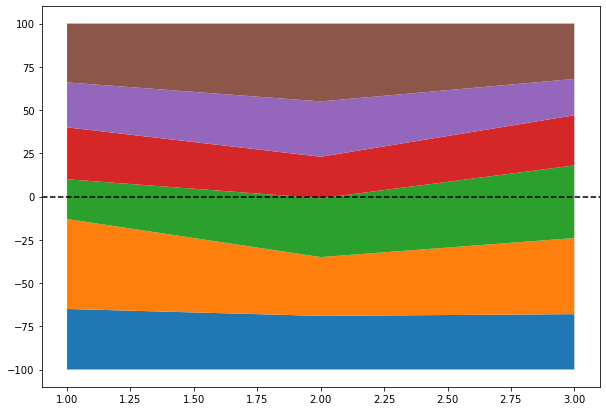

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.stackplot(code, num.values(), baseline="sym")
ax.axhline(0, color="black", ls="--");

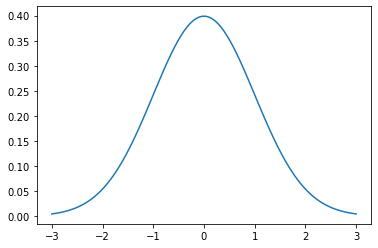

In [6]:
from scipy import stats
grid = np.linspace(-3, 3, num=100)
plt.plot(grid, stats.norm.pdf(grid));

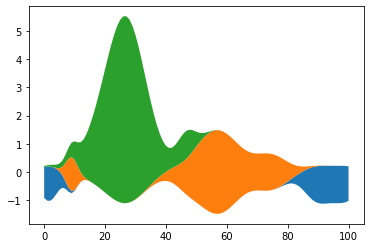

In [11]:
# Fixing random state for reproducibility
np.random.seed(19680801)

def gaussian_mixture(x, n=5):
    """Return a random mixture of *n* Gaussians, evaluated at positions *x*."""
    def add_random_gaussian(a):
        amplitude = 1 / (.1 + np.random.random())
        dx = x[-1] - x[0]
        x0 = (2 * np.random.random() - .5) * dx
        z = 10 / (.1 + np.random.random()) / dx
        a += amplitude * np.exp(-(z * (x - x0))**2)
    a = np.zeros_like(x)
    for j in range(n):
        add_random_gaussian(a)
    return a

x = np.linspace(0, 100, 101)
ys = [gaussian_mixture(x) for _ in range(3)]

fig, ax = plt.subplots()
ax.stackplot(x, ys, baseline='wiggle')
plt.show()